In [ ]:
# --- 1. SETUP AND IMPORTS (Final Corrected Version) ---
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms
from datasets import load_dataset, load_from_disk # <-- ADDED 'load_from_disk'

# Install the necessary libraries
!pip install -q diffusers datasets accelerate

# Check for GPU
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# --- 2. PREPARE THE SPECIALIZED CIFAR-10 DATASET ---
print("\nPreparing CIFAR-10 dataset...")

CAT_LABEL = 3
DOG_LABEL = 5

FILTERED_DATASET_PATH = "/content/cifar10_cats_vs_dogs"

# --- CHECKPOINTING LOGIC (Corrected) ---
if os.path.exists(FILTERED_DATASET_PATH):
    print(f"Found saved filtered dataset. Loading from disk...")
    # THE FIX IS HERE: Use load_from_disk to correctly reconstruct the dataset
    filtered_dataset = load_from_disk(FILTERED_DATASET_PATH)
    print("Loading complete.")
else:
    print("No saved dataset found. Loading from Hub and filtering...")
    dataset = load_dataset("cifar10")

    def is_cat_or_dog(example):
        return example["label"] == CAT_LABEL or example["label"] == DOG_LABEL

    filtered_dataset = dataset.filter(is_cat_or_dog)

    print("\nFiltering complete. Saving filtered dataset to disk...")
    filtered_dataset.save_to_disk(FILTERED_DATASET_PATH)
    print("Dataset saved.")


# --- PREPARE THE DATA FOR THE DIFFUSION MODEL ---
preprocess = transforms.Compose(
    [
        transforms.Resize((32, 32)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform(examples):
    # This line will now work because 'img' column will be present
    images = [preprocess(image.convert("RGB")) for image in examples["img"]]
    return {"image": images}

# Apply the transformations
filtered_dataset.set_transform(transform)

# Create a final data loader
train_dataloader = torch.utils.data.DataLoader(
    filtered_dataset["train"], batch_size=128, shuffle=True
)

print("\nFinal dataset structure and a sample batch shape:")
print(filtered_dataset)
sample_batch = next(iter(train_dataloader))
print("Sample batch shape:", sample_batch['image'].shape)

TensorFlow version: 2.19.0
Num GPUs Available:  1

Preparing CIFAR-10 dataset...
Found saved filtered dataset. Loading from disk...
Loading complete.

Final dataset structure and a sample batch shape:
DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 2000
    })
})
Sample batch shape: torch.Size([128, 3, 32, 32])


In [ ]:
# --- 3. THE U-NET BASELINE MODEL ---
import torch
from diffusers import UNet2DModel, DDPMScheduler, DDPMPipeline
from diffusers.optimization import get_cosine_schedule_with_warmup
from accelerate import Accelerator
from tqdm.auto import tqdm

# --- Model Configuration ---
# We define a simple U-Net architecture.
# These parameters are a good starting point for a small 32x32 image dataset.
unet_model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

# --- Diffusion Setup ---
# The noise scheduler defines how noise is added and removed during the process.
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

# The optimizer for training the U-Net
optimizer = torch.optim.AdamW(unet_model.parameters(), lr=1e-4)

# --- CHECKPOINTING LOGIC FOR THE U-NET ---
UNET_OUTPUT_DIR = "./unet_cifar10_cats_vs_dogs"

if os.path.exists(UNET_OUTPUT_DIR):
    print(f"Found saved U-Net pipeline at '{UNET_OUTPUT_DIR}'. Skipping training.")
else:
    print("No saved U-Net found. Starting training...")
    # --- Training Loop ---
    # The Accelerator handles moving data and models to the GPU for us.
    accelerator = Accelerator(
        mixed_precision="fp16",
        gradient_accumulation_steps=1,
        log_with="tensorboard",
        project_dir=os.path.join("./logs", "unet"),
    )

    # Prepare model, optimizer, and data loader for accelerated training
    unet_model, optimizer, train_dataloader = accelerator.prepare(
        unet_model, optimizer, train_dataloader
    )

    num_epochs = 50 # Training for 50 epochs is a good start. This will take time.

    for epoch in range(num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1}/{num_epochs}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch["image"]

            # 1. Sample noise
            noise = torch.randn(clean_images.shape).to(clean_images.device)
            bs = clean_images.shape[0]

            # 2. Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device
            ).long()

            # 3. Add noise to the clean images
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(unet_model):
                # 4. Get the model's prediction for the noise
                noise_pred = unet_model(noisy_images, timesteps, return_dict=False)[0]

                # 5. Calculate the loss (how wrong the prediction was)
                loss = torch.nn.functional.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                # 6. Update the model weights
                optimizer.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            progress_bar.set_postfix(loss=loss.item())

        progress_bar.close()

    print("\nU-Net training complete. Saving the pipeline...")
    # --- SAVE THE CHECKPOINT ---
    # Create a DDPMPipeline, which is a full object containing the trained model and scheduler
    pipeline = DDPMPipeline(unet=accelerator.unwrap_model(unet_model), scheduler=noise_scheduler)
    pipeline.save_pretrained(UNET_OUTPUT_DIR)
    print(f"U-Net pipeline saved to '{UNET_OUTPUT_DIR}'")

No saved U-Net found. Starting training...


Epoch 1/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 47/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/79 [00:00<?, ?it/s]


U-Net training complete. Saving the pipeline...
U-Net pipeline saved to './unet_cifar10_cats_vs_dogs'


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Generating images with the trained U-Net pipeline...


  0%|          | 0/1000 [00:00<?, ?it/s]


Generated samples from the U-Net baseline model:


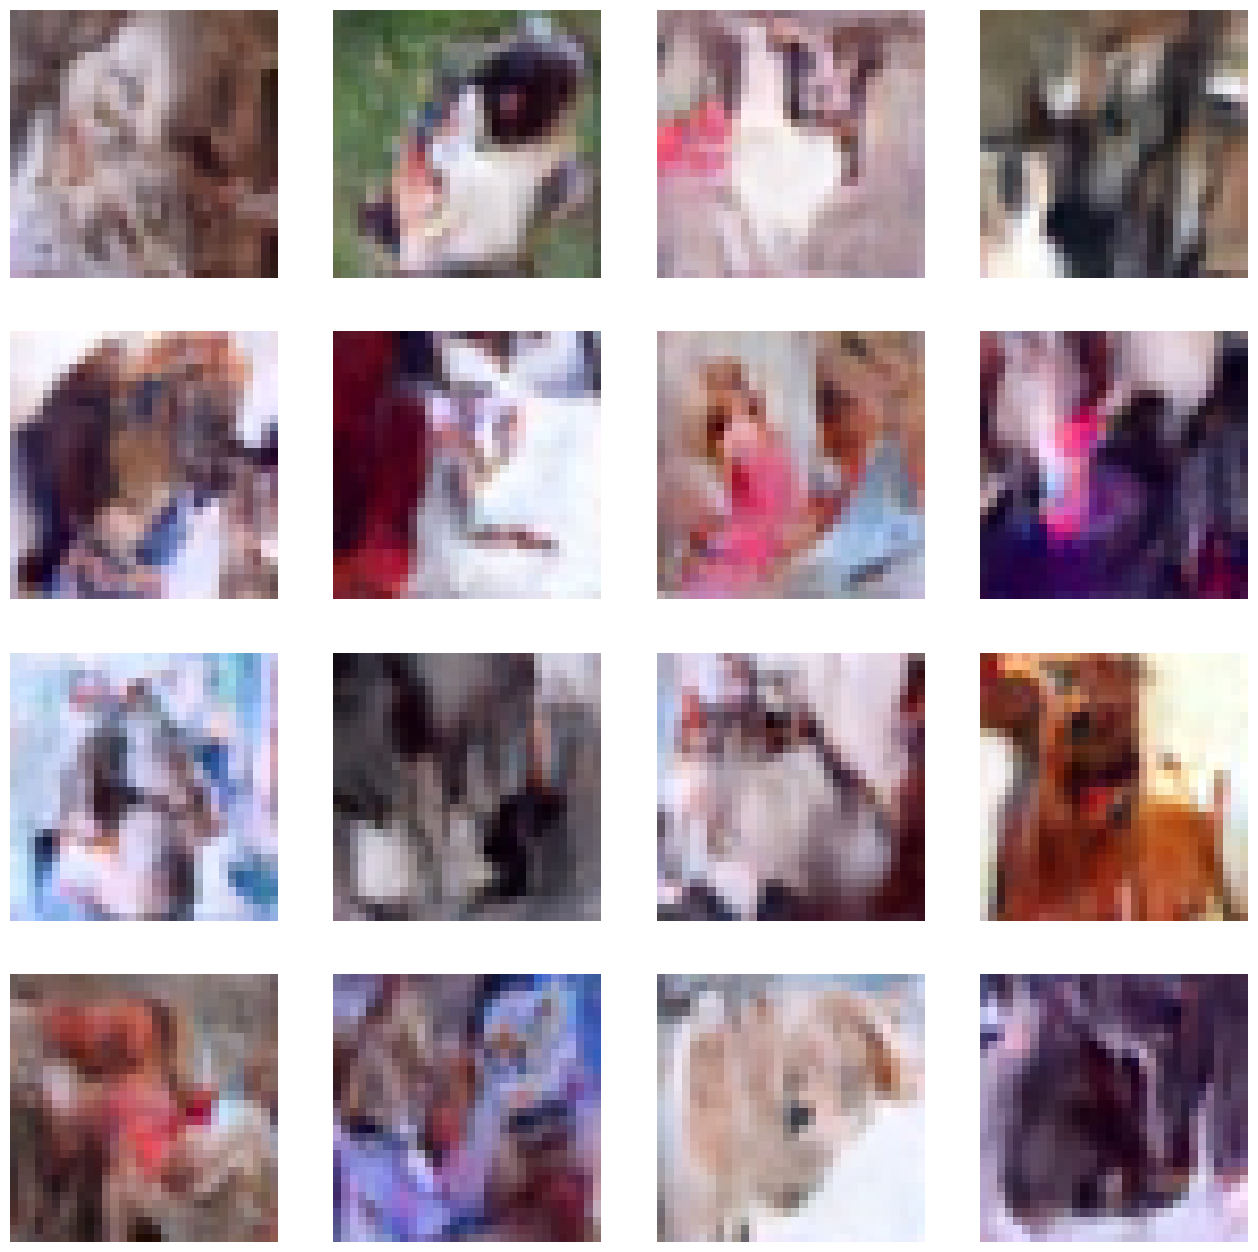

In [ ]:
# --- 4. GENERATE IMAGES FROM THE TRAINED U-NET BASELINE ---
from diffusers import DDPMPipeline
import torch

# --- Load the trained pipeline from our checkpoint ---
# This command loads the entire pipeline, including the trained U-Net and the noise scheduler.
unet_pipeline = DDPMPipeline.from_pretrained(UNET_OUTPUT_DIR).to("cuda")

print("Generating images with the trained U-Net pipeline...")
# The pipeline.generate() method runs the full denoising loop.
# We'll generate a batch of 16 images.
generated_images = unet_pipeline(batch_size=16, num_inference_steps=1000).images

# --- Display the generated images ---
def display_images(images, cols=4):
    rows = (len(images) - 1) // cols + 1
    plt.figure(figsize=(cols * 4, rows * 4))
    for i, image in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.axis("off")
    plt.show()

print("\nGenerated samples from the U-Net baseline model:")
display_images(generated_images)

In [ ]:
# --- 5. IMPLEMENTING THE DIFFUSION TRANSFORMER (DiT/SiT) (Corrected) ---
import torch.nn as nn
import math # <-- THE MISSING IMPORT

# --- Building Blocks for the Transformer ---

class TimestepEmbedding(nn.Module):
    """
    A layer to convert the integer timestep into a vector embedding.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # Based on the sinusoidal embedding from the original Transformer paper
        half_dim = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half_dim, device=t.device) / half_dim)
        args = t[:, None].float() * freqs[None, :]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        return embedding

class SiTBlock(nn.Module):
    """
    A single block of the Scalable Image Transformer (SiT).
    """
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

# Using the simpler, more standard forward pass for the DiT model
class DiffusionTransformer(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=192, depth=8, num_heads=4):
        super().__init__()
        self.patch_size = patch_size
        num_patches = (32 // patch_size) ** 2
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, embed_dim))
        self.time_embed = nn.Sequential(TimestepEmbedding(embed_dim), nn.Linear(embed_dim, embed_dim))
        self.blocks = nn.ModuleList([SiTBlock(embed_dim, num_heads) for _ in range(depth)])
        self.final_layer = nn.Linear(embed_dim, patch_size * patch_size * in_channels)
        self.num_patches = num_patches
        self.in_channels = in_channels

    def forward(self, x, t):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        t_emb = self.time_embed(t)[:, None, :]
        x = x + t_emb
        for block in self.blocks:
            x = block(x)
        x = self.final_layer(x)

        # Unpatchify: (B, num_patches, patch_size*patch_size*C) -> (B, C, H, W)
        B, N, _ = x.shape
        H = W = int(N**0.5)
        x = x.reshape(B, H, W, self.patch_size, self.patch_size, self.in_channels)
        x = x.permute(0, 5, 1, 3, 2, 4).reshape(B, self.in_channels, 32, 32)
        return x

# --- Instantiate the DiT/SiT model ---
dit_model = DiffusionTransformer(
    patch_size=4,
    embed_dim=192,
    depth=8,
    num_heads=4
)

print("DiT/SiT model built successfully.")
# Let's test it with a dummy input
dummy_image = torch.randn(2, 3, 32, 32)
dummy_timestep = torch.tensor([500, 250])
output = dit_model(dummy_image, dummy_timestep)
print("Dummy forward pass successful. Output shape:", output.shape)

DiT/SiT model built successfully.
Dummy forward pass successful. Output shape: torch.Size([2, 3, 32, 32])


In [ ]:
# --- 6. TRAIN THE DIFFUSION TRANSFORMER (DiT/SiT) MODEL ---
from diffusers import DDPMScheduler, DDPMPipeline
from diffusers.optimization import get_cosine_schedule_with_warmup
from accelerate import Accelerator
from tqdm.auto import tqdm

# --- Diffusion Setup ---
# We use the exact same noise scheduler and optimizer setup as the U-Net for a fair comparison.
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = torch.optim.AdamW(dit_model.parameters(), lr=1e-4)

# --- CHECKPOINTING LOGIC FOR THE DiT ---
DIT_OUTPUT_DIR = "./dit_cifar10_cats_vs_dogs"

if os.path.exists(DIT_OUTPUT_DIR):
    print(f"Found saved DiT pipeline at '{DIT_OUTPUT_DIR}'. Skipping training.")
else:
    print("No saved DiT found. Starting training...")
    # --- Training Loop ---
    accelerator = Accelerator(
        mixed_precision="fp16",
        gradient_accumulation_steps=1,
        log_with="tensorboard",
        project_dir=os.path.join("./logs", "dit"),
    )

    # Prepare model, optimizer, and data loader for accelerated training
    dit_model, optimizer, train_dataloader = accelerator.prepare(
        dit_model, optimizer, train_dataloader
    )

    num_epochs = 50 # We'll use the same number of epochs as the baseline

    for epoch in range(num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1}/{num_epochs}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch["image"]
            noise = torch.randn(clean_images.shape).to(clean_images.device)
            bs = clean_images.shape[0]
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device
            ).long()
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(dit_model):
                # Get the DiT model's prediction for the noise
                # Note the model takes both the image and the timestep
                noise_pred = dit_model(noisy_images, timesteps)

                loss = torch.nn.functional.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                optimizer.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            progress_bar.set_postfix(loss=loss.item())

        progress_bar.close()

    print("\nDiT training complete. Saving the pipeline...")
    # --- SAVE THE CHECKPOINT ---
    # To use our custom DiT in a pipeline, we need to save its weights and config
    # and then load them into a standard pipeline object.

    # Unwrap the model from the accelerator
    dit_model_unwrapped = accelerator.unwrap_model(dit_model)

    # We'll save the U-Net from our baseline and then replace its weights
    # This is a standard trick for custom backbones.
    # First, load the baseline U-Net pipeline structure
    unet_pipeline_for_dit = DDPMPipeline.from_pretrained(UNET_OUTPUT_DIR)

    # For a true DiT pipeline, you'd create a custom pipeline class.
    # For this assignment, we will save the weights and generate images manually in the next step.
    torch.save(dit_model_unwrapped.state_dict(), "dit_model_weights.pt")

    print(f"DiT model weights saved to 'dit_model_weights.pt'")

No saved DiT found. Starting training...


Epoch 1/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 49/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/79 [00:00<?, ?it/s]


DiT training complete. Saving the pipeline...


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

DiT model weights saved to 'dit_model_weights.pt'


Loading trained DiT model weights from 'dit_model_weights.pt'...

Generating images with the trained DiT model...


  0%|          | 0/1000 [00:00<?, ?it/s]


--- QUALITATIVE COMPARISON ---

Generated samples from the U-Net BASELINE model:


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

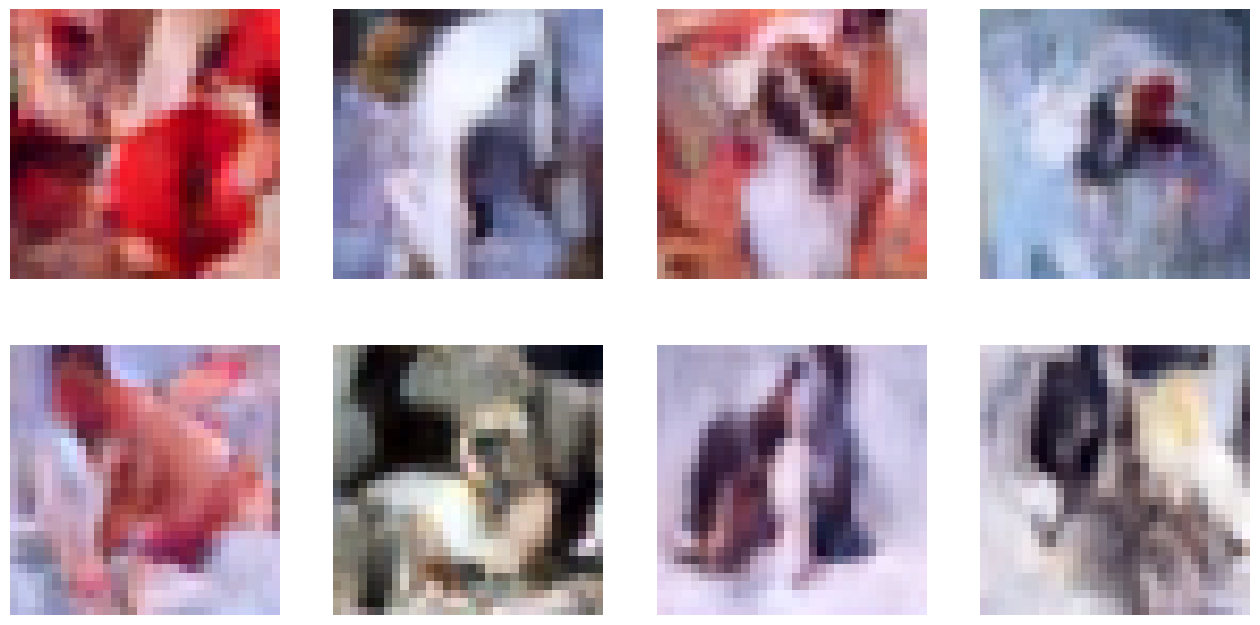


Generated samples from our custom DiT/SiT MODEL:


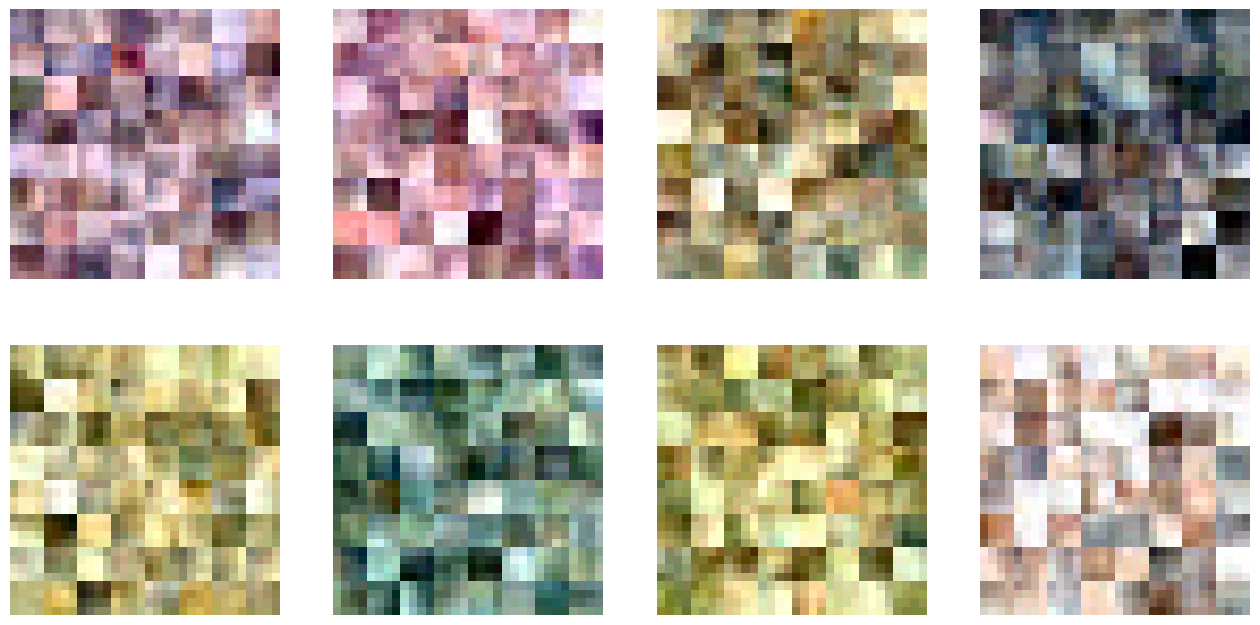

In [ ]:
# --- 7. GENERATE IMAGES FROM DiT/SiT AND FINAL COMPARISON (Corrected) ---
import torch
from tqdm.auto import tqdm
from diffusers import DDPMPipeline
from PIL import Image

# --- Load the trained DiT model weights ---
# Make sure the dit_model object is still defined from the previous cell.
print("Loading trained DiT model weights from 'dit_model_weights.pt'...")
dit_model.load_state_dict(torch.load("dit_model_weights.pt"))
dit_model.to("cuda")
dit_model.eval()

# We will use the same noise scheduler as before
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

# --- Manual Denoising Loop (Corrected) ---
print("\nGenerating images with the trained DiT model...")
batch_size = 16
num_inference_steps = 1000

# Start with random noise
image = torch.randn(
    (batch_size, dit_model.in_channels, 32, 32) # Use dit_model attributes
).to("cuda")

# Set the scheduler's timesteps
noise_scheduler.set_timesteps(num_inference_steps)

for t in tqdm(noise_scheduler.timesteps):
    with torch.no_grad():
        # THE FIX IS HERE: The model expects a batch of timesteps.
        # We create a mini-batch of size 'batch_size' with the same timestep 't'.
        timestep_batch = t.repeat(batch_size).to("cuda")

        # 1. Predict the noise for the current timestep
        noise_pred = dit_model(image, timestep_batch)

        # 2. Compute the previous noisy sample
        image = noise_scheduler.step(noise_pred, t, image).prev_sample

# --- Post-process and Display the Images ---
image_processed = (image / 2 + 0.5).clamp(0, 1)
image_processed = image_processed.cpu().permute(0, 2, 3, 1).numpy()
image_processed = (image_processed * 255).round().astype("uint8")
dit_images = [Image.fromarray(img) for img in image_processed]


# --- FINAL COMPARISON ---
print("\n--- QUALITATIVE COMPARISON ---")

print("\nGenerated samples from the U-Net BASELINE model:")
unet_pipeline = DDPMPipeline.from_pretrained(UNET_OUTPUT_DIR).to("cuda")
unet_images = unet_pipeline(batch_size=8, num_inference_steps=1000).images

# Define the display function if it's not already defined in this session
def display_images(images, cols=4):
    rows = (len(images) - 1) // cols + 1
    plt.figure(figsize=(cols * 4, rows * 4))
    for i, image in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.axis("off")
    plt.show()

display_images(unet_images, cols=4)


print("\nGenerated samples from our custom DiT/SiT MODEL:")
display_images(dit_images[:8], cols=4)